In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2 as cv

In [3]:
meta = pd.read_csv('../metadata.csv')

In [4]:
i = 0
nv = 0
not_nv = 0
images = []
labels = []
for row in meta.iterrows():
    img_name = row[1]['image_id']
    dx = row[1]['dx']
    img_path = f'../images/{img_name}.jpg'
    img = cv.imread(img_path)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img = cv.resize(img, (224, 224))
    images.append(img)
    if(dx != 'nv'):
        dx = 'not_nv'
        not_nv += 1
    else: nv += 1
    labels.append(dx)
    if i == 5000: break
    i+=1

In [5]:
print(f'nv: {nv}, not_nv: {not_nv}')
images = np.array(images)/255.0
labels = np.array(labels)

nv: 2026, not_nv: 2975


In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels = le.fit_transform(labels)

In [7]:
print(images[0].shape)
print(le.inverse_transform([labels[3000]]))
print(labels[0])
# {'not_nv': 0, 'nv': 1}

(224, 224, 3)
['nv']
0


In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

In [ ]:
nv, not_nv = 0, 0
for i in y_test:
    if i == 0: not_nv += 1
    else: nv += 1
print(f'nv: {nv}, not_nv: {not_nv}')

nv: 406, not_nv: 595


In [ ]:
import tensorflow as tf
# baseline cnn model

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 111, 111, 32)      0         
 g2D)                                                            
                                                                 
 conv2d_6 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 flatten_3 (Flatten)         (None, 186624)            0         
                                                                 
 dense_6 (Dense)             (None, 32)               

In [ ]:
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
125/125 [==============================] - 215s 2s/step - loss: 0.3221 - accuracy: 0.8790 - val_loss: 0.2485 - val_accuracy: 0.8971
Epoch 2/5
125/125 [==============================] - 217s 2s/step - loss: 0.1757 - accuracy: 0.9340 - val_loss: 0.1451 - val_accuracy: 0.9491
Epoch 3/5
125/125 [==============================] - 178s 1s/step - loss: 0.1532 - accuracy: 0.9440 - val_loss: 0.2672 - val_accuracy: 0.8941
Epoch 4/5
125/125 [==============================] - 180s 1s/step - loss: 0.1723 - accuracy: 0.9352 - val_loss: 0.1440 - val_accuracy: 0.9461
Epoch 5/5
125/125 [==============================] - 175s 1s/step - loss: 0.1555 - accuracy: 0.9435 - val_loss: 0.1397 - val_accuracy: 0.9471


In [ ]:
# evalute
model.save('bifurcate.h5')
loss, acc = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, Acc: {acc}')

32/32 [==============================] - 14s 445ms/step - loss: 0.1397 - accuracy: 0.9471
Loss: 0.13969118893146515, Acc: 0.9470529556274414


1/1 [==============================] - 0s 25ms/step


Text(0.5, 1.0, 'True: not_nv and Predicted: not_nv')

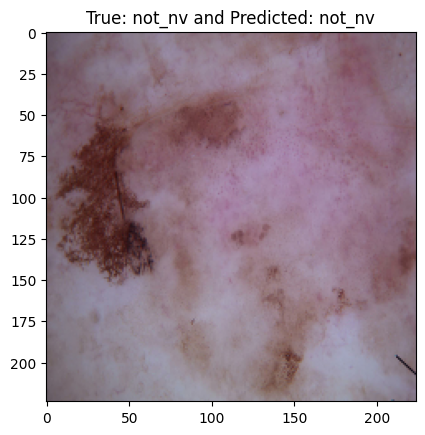

In [ ]:
import random
i = random.randint(0, len(X_test))
img = X_test[i]
plt.imshow(img)
true_label = le.inverse_transform([y_test[i]])
prediction = model.predict(np.array([img]))
if prediction > 0.5: prediction = 'nv'
else: prediction = 'not_nv'
plt.title(f'True: {true_label[0]} and Predicted: {prediction}')

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.show()

NameError: name 'model' is not defined